# 1. Import Libraries


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

# 2. Load Dataset


In [88]:
df = pd.read_csv("data/sales_data.csv")  
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


 # 3. Data Cleaning & EDA

In [90]:
df.isna().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [91]:
df.duplicated().sum()

17

In [92]:
df.drop_duplicates(inplace=True)

In [93]:
df.duplicated().sum()

0

In [94]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


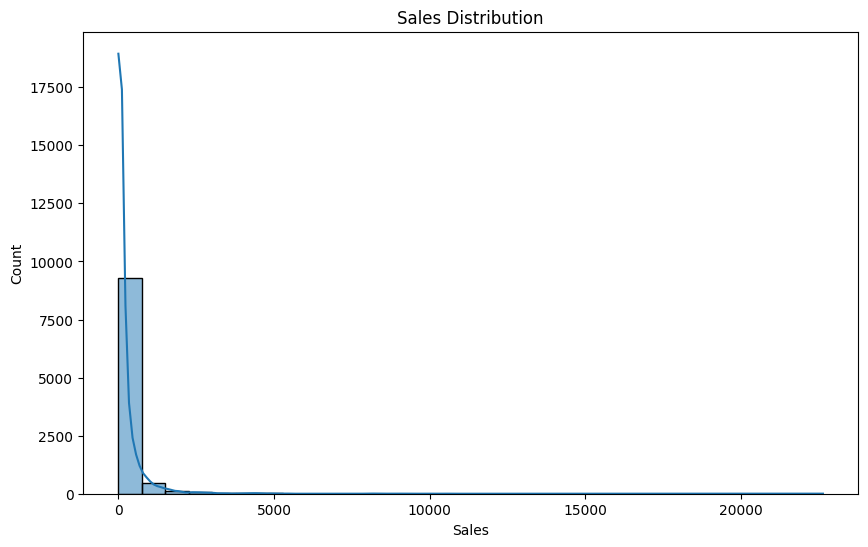

In [95]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.show()

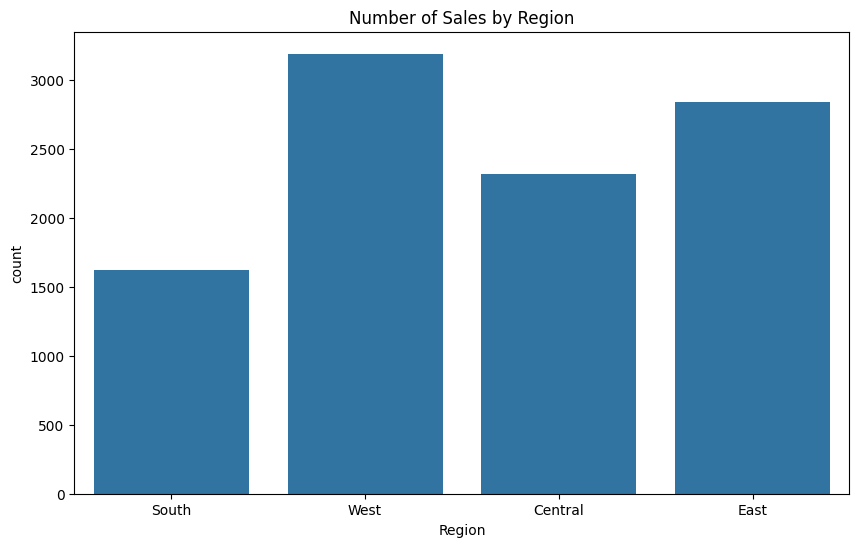

In [96]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Region')
plt.title('Number of Sales by Region')
plt.show()


# 5. Feature Engineering


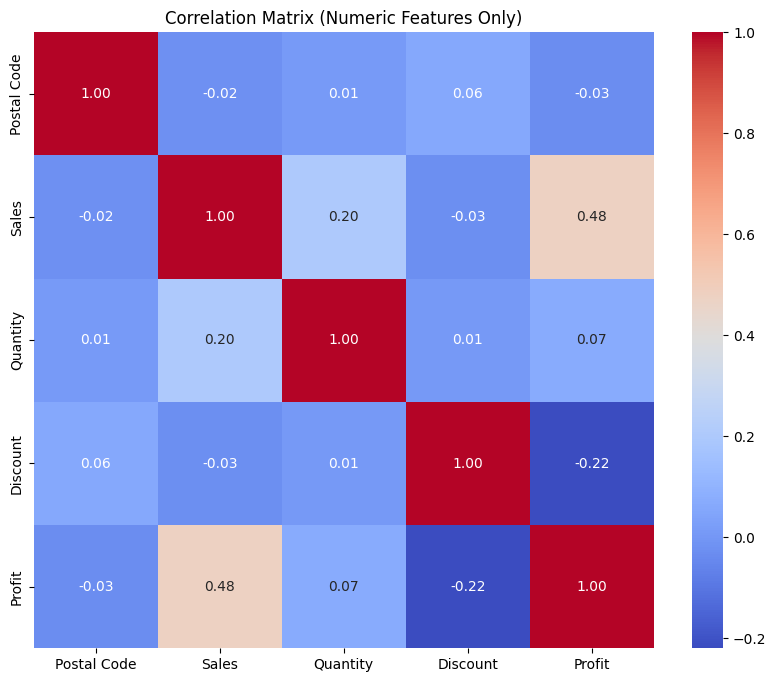

In [102]:
numeric_cols = df.select_dtypes(include='number')

if 'Sales' not in numeric_cols.columns:
    numeric_cols = numeric_cols.join(df['Sales'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

 - Sales shows the strongest positive correlation with Profit, while Discount has a clear negative impact on Profit.  
 - Other numeric features (Quantity, Postal Code) show very weak or no meaningful relationship with Sales or Profit.


In [97]:
df.select_dtypes(include='object').columns


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category'],
      dtype='object')

In [ ]:
# Encode only necessary categorical columns
categorical_features = ['Category', 'Sub-Category', 'Region']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# X = all numeric features except target
X = df_encoded.drop(['Sales', 'Ship Mode', 'Segment', 'Country', 'City', 'State'], axis=1, errors='ignore')
y = df_encoded['Sales']

# Convert boolean columns to int (dummies)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.apply(pd.to_numeric)
y = y.apply(pd.to_numeric)


# 4. Model Training


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
#train
model.fit(X_train, y_train)

LinearRegression()

In [104]:
#predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")



Model Performance:
Mean Squared Error (MSE): 242665.71
R² Score: 0.3241


# 5. Model Saving

In [105]:
# Save Model using Pickle

with open("sales_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully as sales_model.pkl")

Model saved successfully as sales_model.pkl
